1. Preprocesamiento de Datos

En esta etapa limpiamos los datos, manejamos los valores nulos y eliminamos columnas que no aportan valor analítico (como el número de fila). Aquí no convertiremos las variables de texto a números (One-Hot Encoding) ni escalaremos los datos, ya que mantenerlos en su formato original facilita la interpretación de los gráficos.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('../data/raw/dataset_crediticio_chile-1-1.csv')

# 2. Eliminar columnas que no aportan valor analítico
df = df.drop(columns=['No.', 'ScoreRiesgo'], errors='ignore')

# 3. Manejo INTELIGENTE de valores nulos (Solución al comentario del profesor)
# Las calificaciones nulas significan "Sin Historial", les ponemos -1
df['Peor_Calificacion_36M'] = df['Peor_Calificacion_36M'].fillna(-1)
df['Peor_Calificacion_12M'] = df['Peor_Calificacion_12M'].fillna(-1)

# Al empleo nulo le asignamos una categoría propia
df['Tipo_Empleo'] = df['Tipo_Empleo'].fillna('DESCONOCIDO')

# Para el resto de columnas numéricas, usamos la mediana
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Para el resto de columnas de texto, usamos la moda (el valor más común)
cat_cols = df.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Preprocesamiento completado: Datos limpios y listos para explorar.")

✅ Preprocesamiento completado: Datos limpios y listos para explorar.


2. Análisis Exploratorio de Datos (EDA)

Aquí buscamos entender las estadísticas descriptivas básicas del conjunto de datos (medias, valores mínimos, máximos) y cómo se distribuyen las categorías.

In [15]:
print("--- Resumen de Variables Numéricas ---")
display(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

print("\n--- Resumen de Variables Categóricas (Texto) ---")
display(df.describe(include=['object']))

print("\n--- Distribución de Riesgo Crediticio (%) ---")
print(df['RiesgoAlto'].value_counts(normalize=True) * 100)

--- Resumen de Variables Numéricas ---


,Tiene_Vehiculo,Edad,Num_Entidades_Deuda,Tiene_Tarjeta,Saldo_Tarjeta_CLP,Saldo_Total_CLP,Variacion_Endeudamiento,Peor_Calificacion_36M,Peor_Calificacion_12M,Reportes_Central_36M,Reportes_Central_12M,Promedio_Saldo_CLP,Maximo_Saldo_CLP,Ingreso_CLP,Ratio_Saldo_Ingreso,RiesgoAlto
count,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00
mean,0.14,40.83,1.74,0.43,1077308.26,4074351.50,-0.04,1.03,0.17,27.39,10.71,3818433.37,6203071.20,2273164.33,0.17,0.25
std,0.34,11.78,1.09,0.50,2370446.16,5247420.19,5.61,1.37,0.51,9.36,2.84,4636673.42,7084091.78,2087078.98,0.22,0.43
min,0.00,22.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-1.00,0.00,0.00,0.00,0.00,170000.00,0.00,0.00
25%,0.00,31.00,1.00,0.00,0.00,840416.25,-0.50,0.00,0.00,21.00,11.00,1223747.49,2125000.00,1300500.00,0.04,0.00
50%,0.00,39.00,2.00,0.00,0.00,2343212.00,-0.22,0.00,0.00,30.00,12.00,2449474.41,4250000.00,1819000.00,0.10,0.00
75%,0.00,50.00,2.00,1.00,1016281.25,5406620.50,-0.02,1.00,0.00,36.00,12.00,4807140.25,8014059.25,2550000.00,0.23,0.00
max,1.00,70.00,6.00,1.00,24341543.50,78859600.00,273.03,4.00,4.00,36.00,12.00,77011547.51,127076419.50,59500000.00,5.88,1.00



--- Resumen de Variables Categóricas (Texto) ---


,Sexo,Tipo_Empleo,Ciudad_Chile
count,4266,4266,4266
unique,2,3,7
top,M,IND,SANTIAGO
freq,2151,2667,3670



--- Distribución de Riesgo Crediticio (%) ---
RiesgoAlto
0    75.035162
1    24.964838
Name: proportion, dtype: float64


3. Visualización de Datos

Estos bloques de código generarán los gráficos clave para entender el comportamiento de los clientes y qué variables parecen tener relación con el riesgo crediticio.

Gráfico 1: Distribución del Riesgo (Desbalanceo de clases)

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_18668\592526175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])


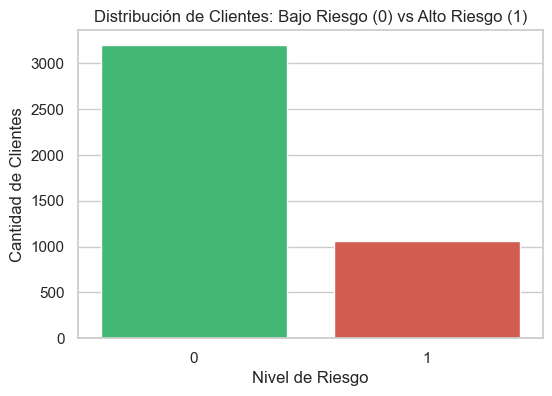

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clientes: Bajo Riesgo (0) vs Alto Riesgo (1)')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Clientes')

plt.show()

Gráfico 2: Variables Demográficas vs Riesgo

Analizaremos cómo se distribuye el riesgo según el sexo y si el cliente tiene vehículo.

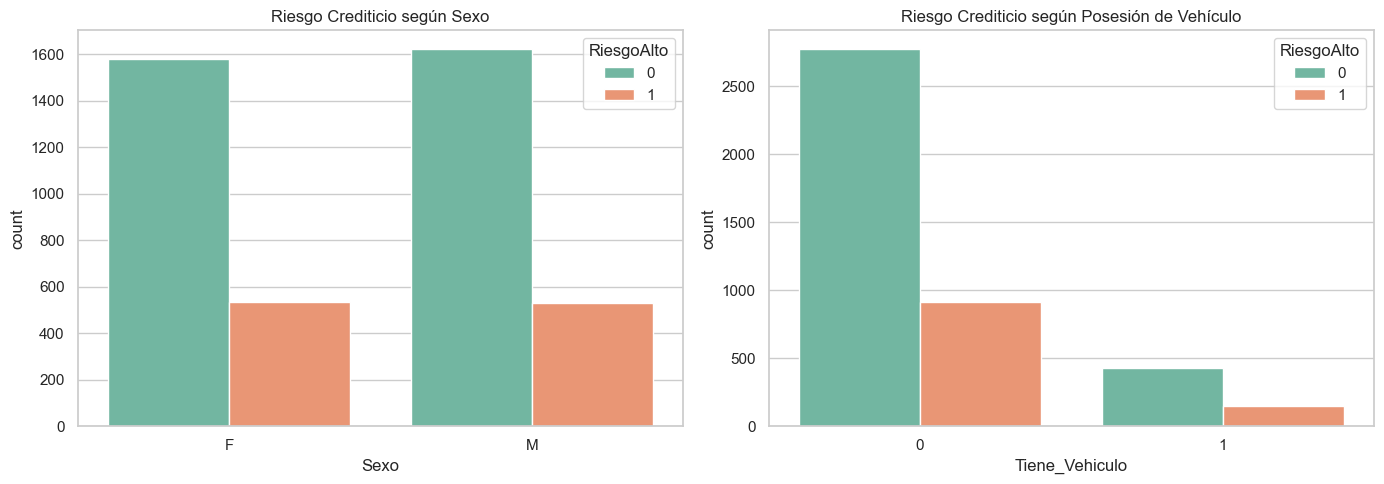

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Sexo', hue='RiesgoAlto', ax=axes[0], palette='Set2')
axes[0].set_title('Riesgo Crediticio según Sexo')

sns.countplot(data=df, x='Tiene_Vehiculo', hue='RiesgoAlto', ax=axes[1], palette='Set2')
axes[1].set_title('Riesgo Crediticio según Posesión de Vehículo')

plt.tight_layout()
plt.show()

Gráfico 3: Distribución de Edad e Ingresos

Usaremos diagramas de caja (Boxplots) para ver si los clientes de alto riesgo tienden a ser más jóvenes o a tener menores ingresos.

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_18668\3929059103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Edad', ax=axes[0], palette='pastel')
C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_18668\3929059103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Ingreso_CLP', ax=axes[1], palette='pastel')


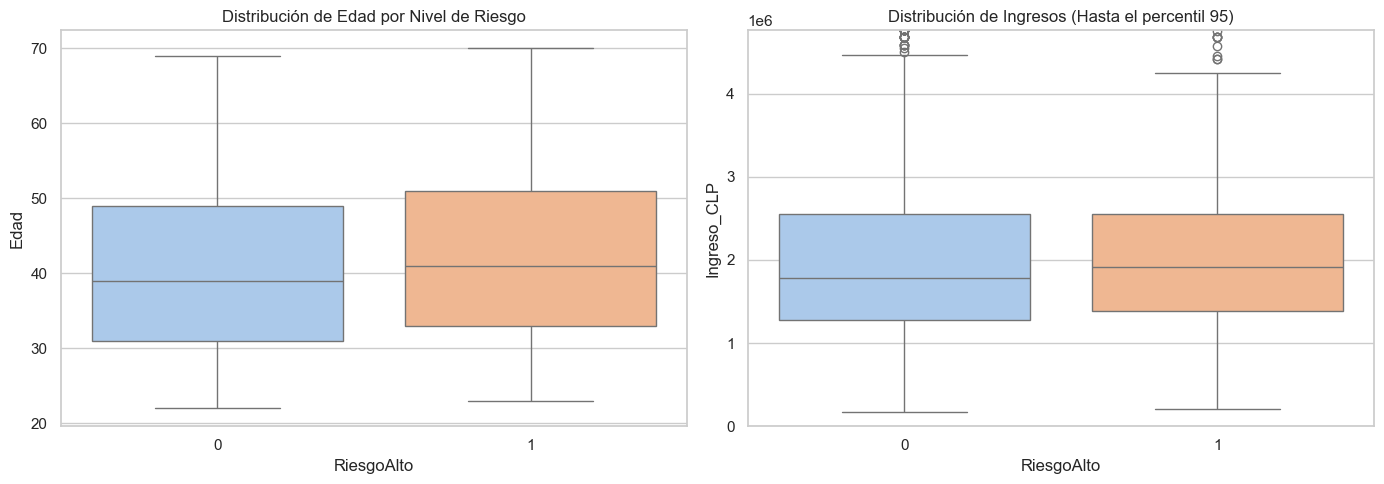

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='RiesgoAlto', y='Edad', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución de Edad por Nivel de Riesgo')

sns.boxplot(data=df, x='RiesgoAlto', y='Ingreso_CLP', ax=axes[1], palette='pastel')
# Limitamos el eje Y para que los sueldos millonarios atípicos no deformen la vista
axes[1].set_ylim(0, df['Ingreso_CLP'].quantile(0.95)) 
axes[1].set_title('Distribución de Ingresos (Hasta el percentil 95)')

plt.tight_layout()
plt.show()

Gráfico 4: Comportamiento Financiero

Analizamos la cantidad de deudas activas y los reportes negativos.

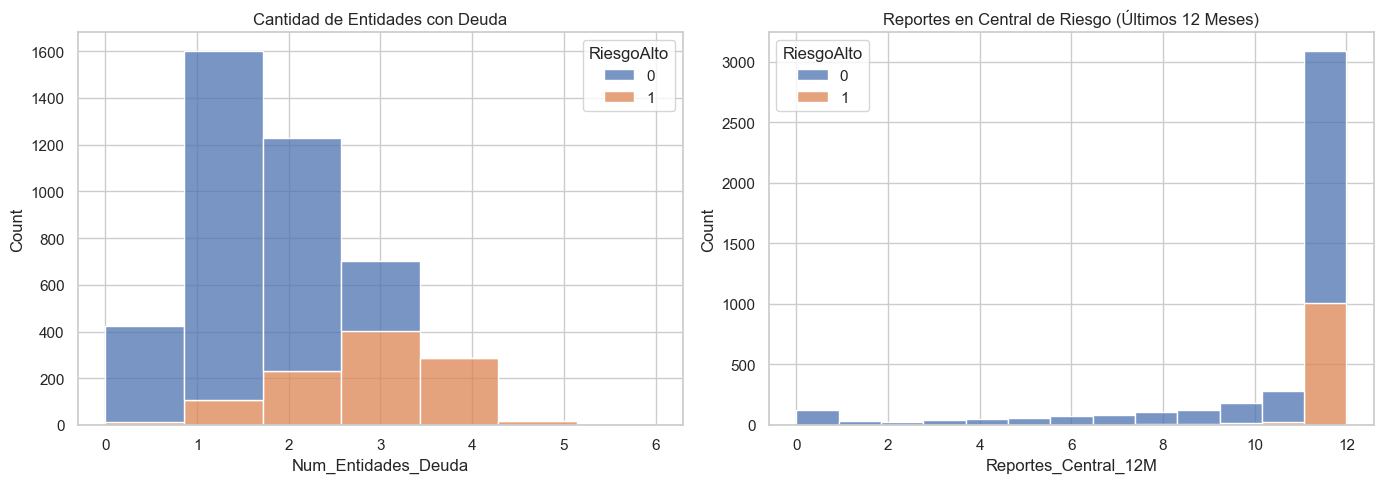

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Num_Entidades_Deuda', hue='RiesgoAlto', multiple="stack", bins=7, ax=axes[0])
axes[0].set_title('Cantidad de Entidades con Deuda')

sns.histplot(data=df, x='Reportes_Central_12M', hue='RiesgoAlto', multiple="stack", bins=13, ax=axes[1])
axes[1].set_title('Reportes en Central de Riesgo (Últimos 12 Meses)')

plt.tight_layout()
plt.show()

Gráfico 5: Matriz de Correlación

Este gráfico es vital en el EDA. Muestra cómo se relacionan las variables numéricas entre sí. Tonos más oscuros o intensos indican una fuerte relación (positiva o negativa).

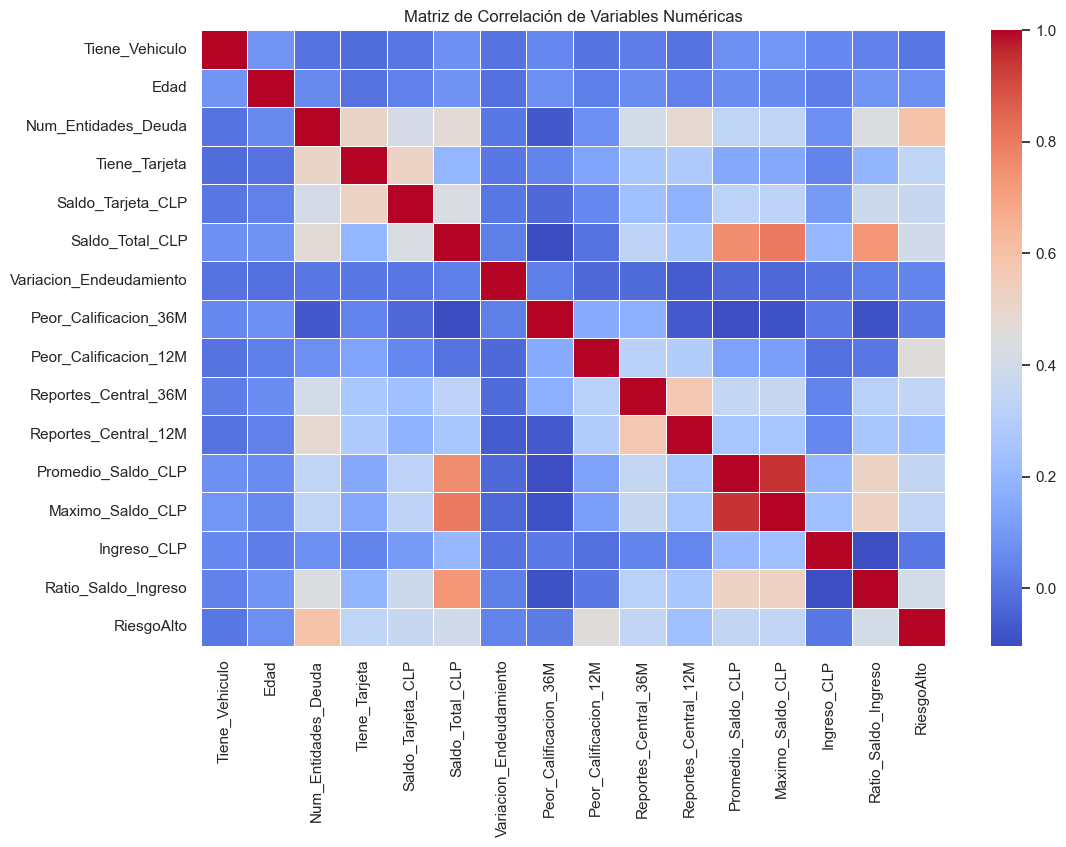

In [20]:
plt.figure(figsize=(12, 8))

# Seleccionamos solo las numéricas para la correlación matemática
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')

plt.show()